Descripción del Notebook:

En este notebook aplicaremos la técnica de Feature Extraction (Extracción de Características). Aprenderemos a congelar completamente los pesos del modelo preentrenado (base_model.trainable = False) para entrenar únicamente el nuevo clasificador sin alterar las características generales aprendidas en ImageNet.

🐍 Importación de Librerías y Configuración

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

os.makedirs('../image', exist_ok=True)

🐍 Parte 1: Congelado del Modelo Base

In [2]:
base_model = MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)

# Paso clave de Feature Extraction: congelar todas las capas base
base_model.trainable = False

print(
    '¿El modelo base es entrenable?:',
    base_model.trainable,
)

¿El modelo base es entrenable?: False


🐍 Parte 2: Compilación y Verificación de Parámetros

In [3]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
outputs = tf.keras.layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

# Verificar cuántos parámetros son entrenables vs no entrenables
trainable_count = count_params = sum(
    [tf.keras.backend.count_params(w) for w in model.trainable_weights]
)
non_trainable_count = sum(
    [tf.keras.backend.count_params(w) for w in model.non_trainable_weights]
)

print(f'Parámetros Entrenables: {trainable_count:,}')
print(f'Parámetros No Entrenables (Congelados): {non_trainable_count:,}')

Parámetros Entrenables: 2,562
Parámetros No Entrenables (Congelados): 2,257,984


🐍 Parte 3: Generación del Esquema de Feature Extraction

C:\Users\acer\AppData\Local\Temp\ipykernel_1432\816072581.py:49: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\acer\AppData\Local\Temp\ipykernel_1432\816072581.py:49: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\acer\AppData\Local\Temp\ipykernel_1432\816072581.py:50: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  plt.savefig(
C:\Users\acer\AppData\Local\Temp\ipykernel_1432\816072581.py:50: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig(
c:\Users\acer\Transfer-Learning-Masterclass\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128274 (\N{LOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\acer\Transfer-Learning-Masterclass\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.


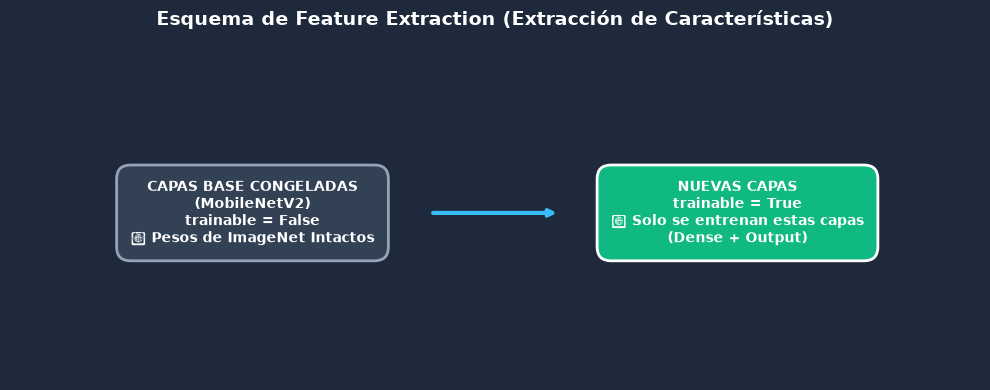

Imagen guardada en: ../image/feature_extraction_schema.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 4), facecolor='#1e293b')
ax.set_facecolor('#1e293b')

ax.text(
    1.5,
    0.5,
    'CAPAS BASE CONGELADAS\n(MobileNetV2)\ntrainable = False\n🔒 Pesos de'
    ' ImageNet Intactos',
    ha='center',
    va='center',
    color='white',
    weight='bold',
    bbox=dict(
        boxstyle='round,pad=1', facecolor='#334155', edgecolor='#94a3b8', lw=2
    ),
)

ax.annotate(
    '',
    xy=(3.4, 0.5),
    xytext=(2.6, 0.5),
    arrowprops=dict(arrowstyle='->', color='#38bdf8', lw=3),
)

ax.text(
    4.5,
    0.5,
    'NUEVAS CAPAS\ntrainable = True\n🔥 Solo se entrenan estas capas\n(Dense +'
    ' Output)',
    ha='center',
    va='center',
    color='white',
    weight='bold',
    bbox=dict(
        boxstyle='round,pad=1', facecolor='#10b981', edgecolor='white', lw=2
    ),
)

ax.set_xlim(0, 6)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title(
    'Esquema de Feature Extraction (Extracción de Características)',
    color='white',
    fontsize=14,
    pad=15,
    weight='bold',
)
plt.tight_layout()
plt.savefig(
    '../image/feature_extraction_schema.png',
    dpi=300,
    facecolor=fig.get_facecolor(),
)
plt.show()
print("Imagen guardada en: ../image/feature_extraction_schema.png")

Resumen de lo aprendido:

*   Fijación de base_model.trainable = False para proteger las representaciones aprendidas en ImageNet.

*   Verificación que más de 2.2 millones de parámetros quedaron congelados y solo la capa densa final permaneció entrenable.

*   Generación y exportación de la ilustración explicativa feature_extraction_schema.png.